In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

In [5]:
df=load_diabetes(as_frame=True).frame

In [6]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='object')

In [8]:
from sklearn.tree import DecisionTreeRegressor

# Split X and y
X = df.drop("target", axis=1)
y = df["target"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Decision Tree Regressor
model = DecisionTreeRegressor(
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


In [11]:
from sklearn.metrics import mean_squared_error

In [12]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# MSE
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

Train MSE: 0.0
Test MSE: 4976.797752808989


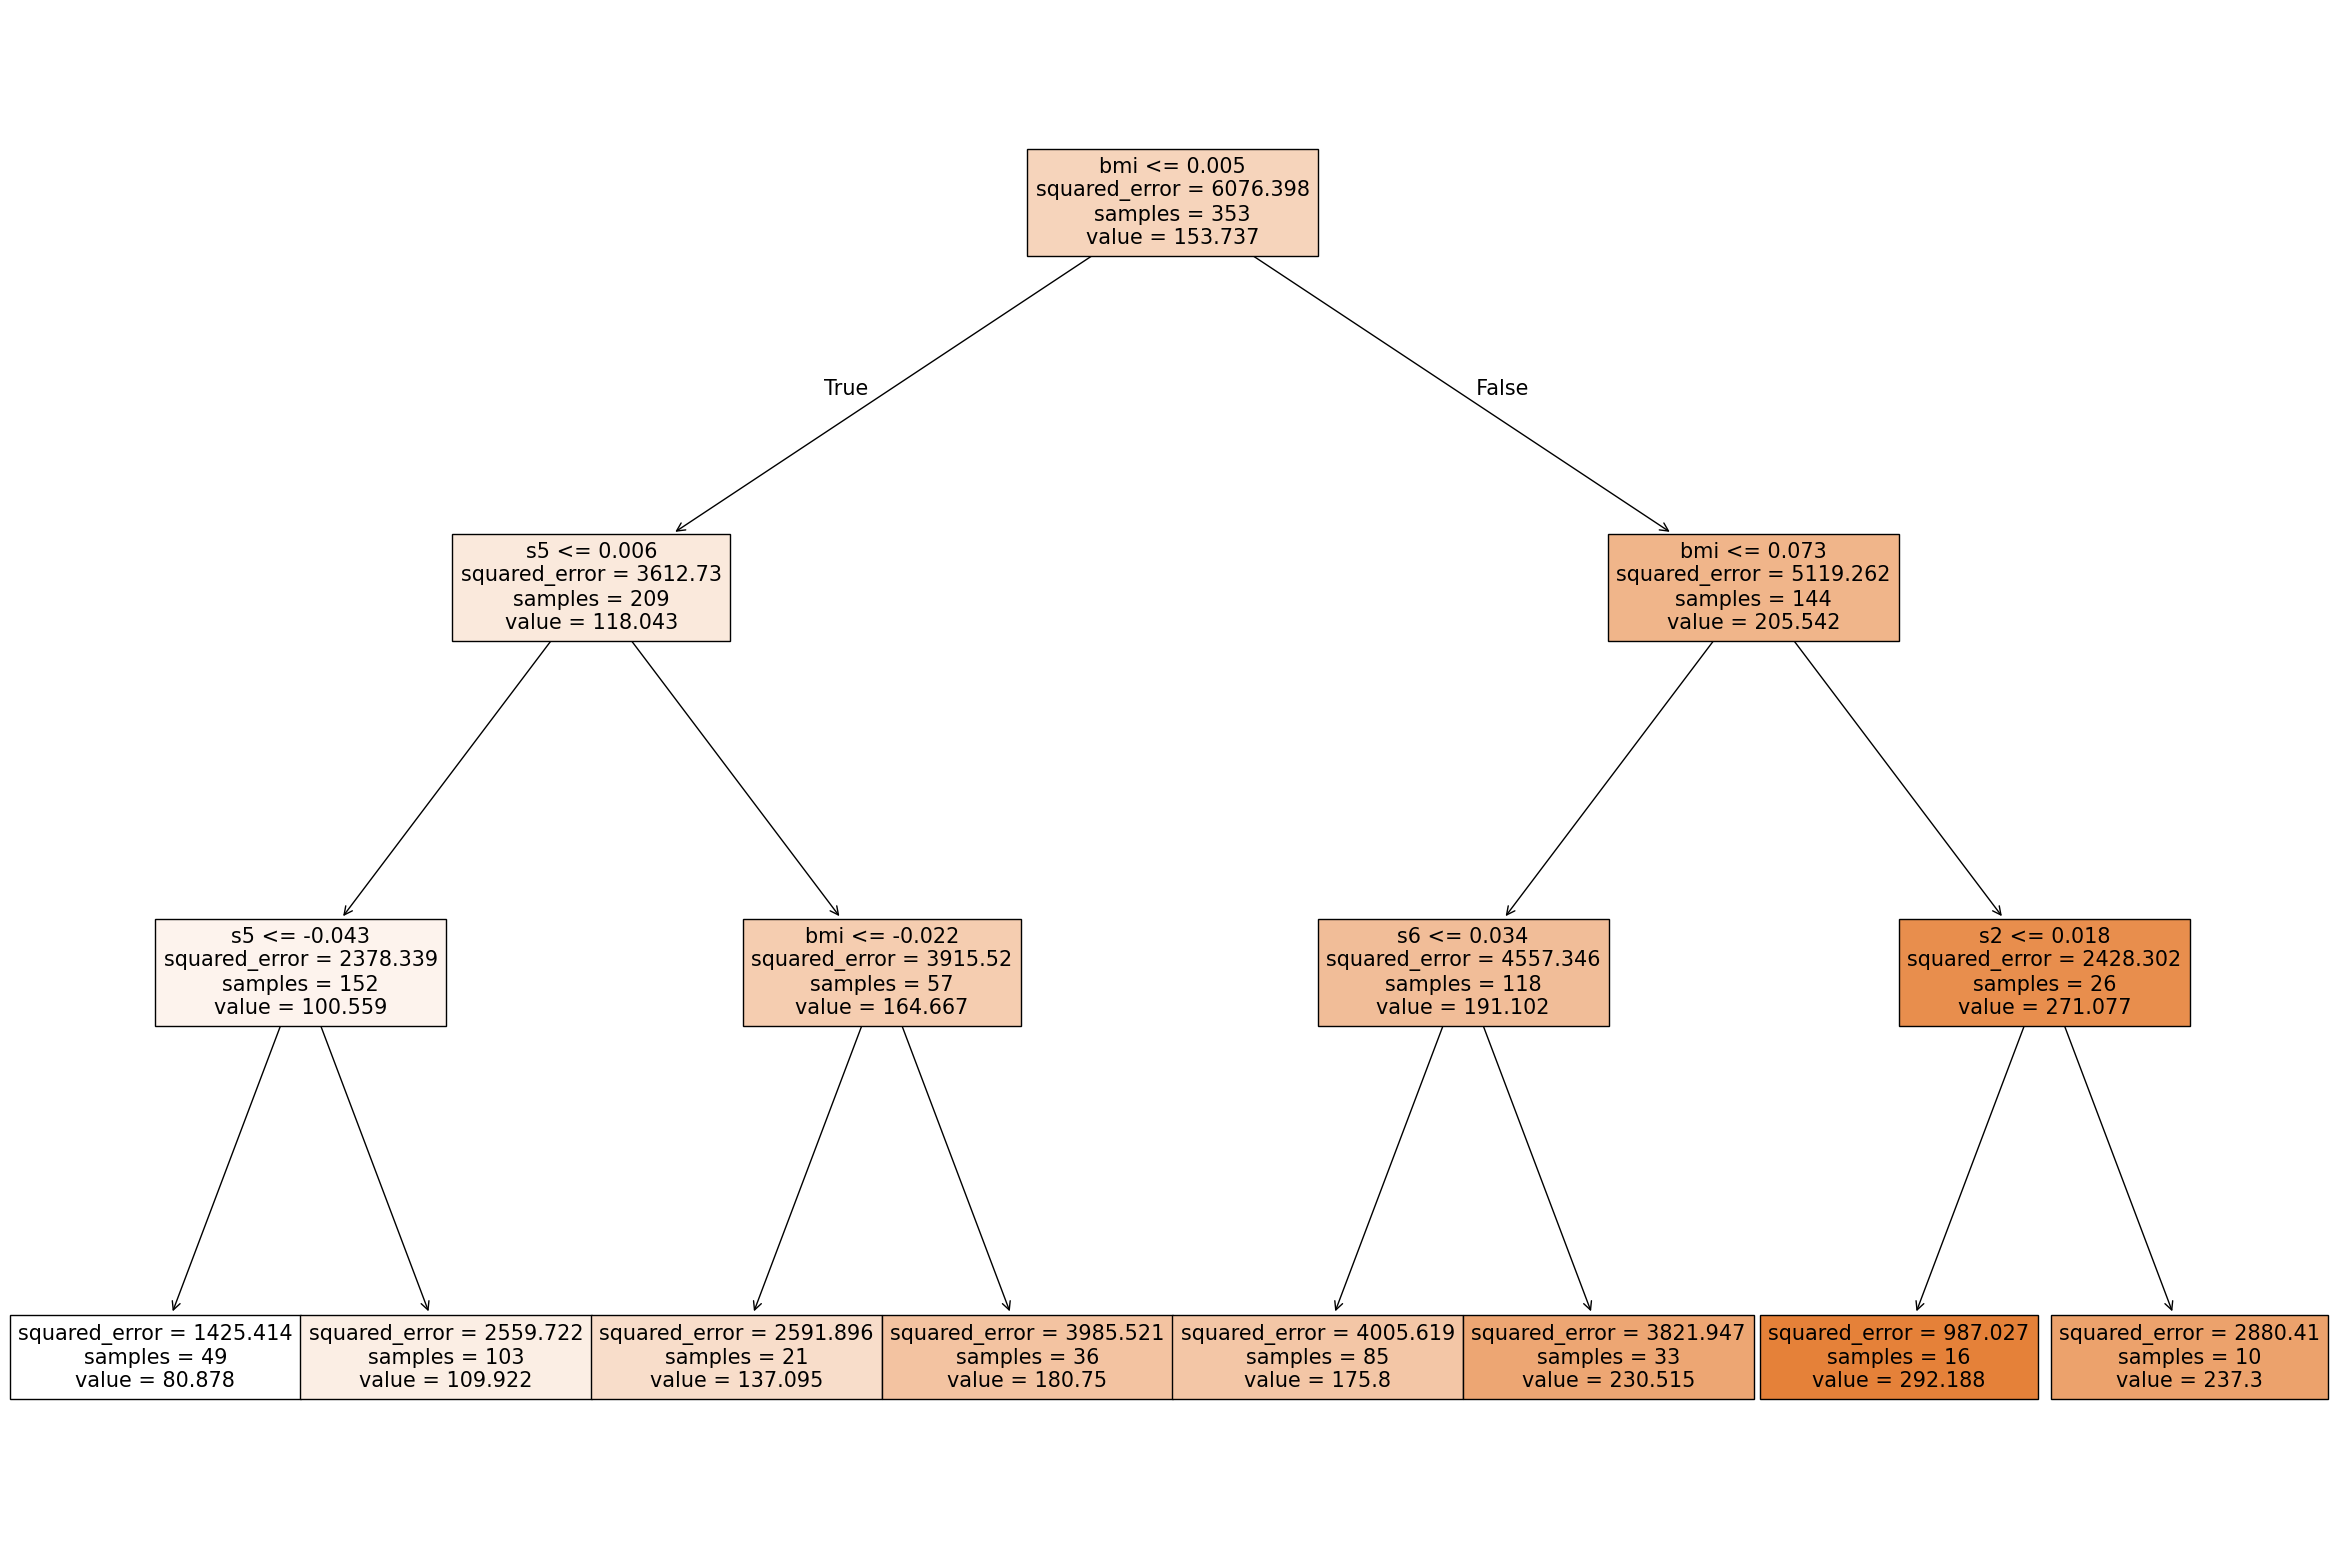

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 20))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True
)

plt.show()

In [13]:
model = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=10,
    min_samples_split=10,
    random_state=42
)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Train MSE: 2633.756689248444
Test MSE: 3150.6051154756356


In [14]:
for depth in [2, 3, 4, 5, 6, 8, 10]:
    model = DecisionTreeRegressor(
        max_depth=depth,
        min_samples_leaf=10,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    print(
        depth,
        "Train MSE:", mean_squared_error(y_train, train_pred),
        "Test MSE:", mean_squared_error(y_test, test_pred)
    )

2 Train MSE: 3358.6253812657023 Test MSE: 3735.4996177389003
3 Train MSE: 2953.551227747737 Test MSE: 3106.722111788698
4 Train MSE: 2633.756689248444 Test MSE: 3150.6051154756356
5 Train MSE: 2400.4155101981664 Test MSE: 3106.868878207416
6 Train MSE: 2273.248053971239 Test MSE: 3268.5946684161186
8 Train MSE: 2097.404110029597 Test MSE: 3545.020730041851
10 Train MSE: 2097.404110029597 Test MSE: 3545.020730041851


In [15]:
model = DecisionTreeRegressor(
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Train MSE: 2953.551227747737
Test MSE: 3106.722111788698


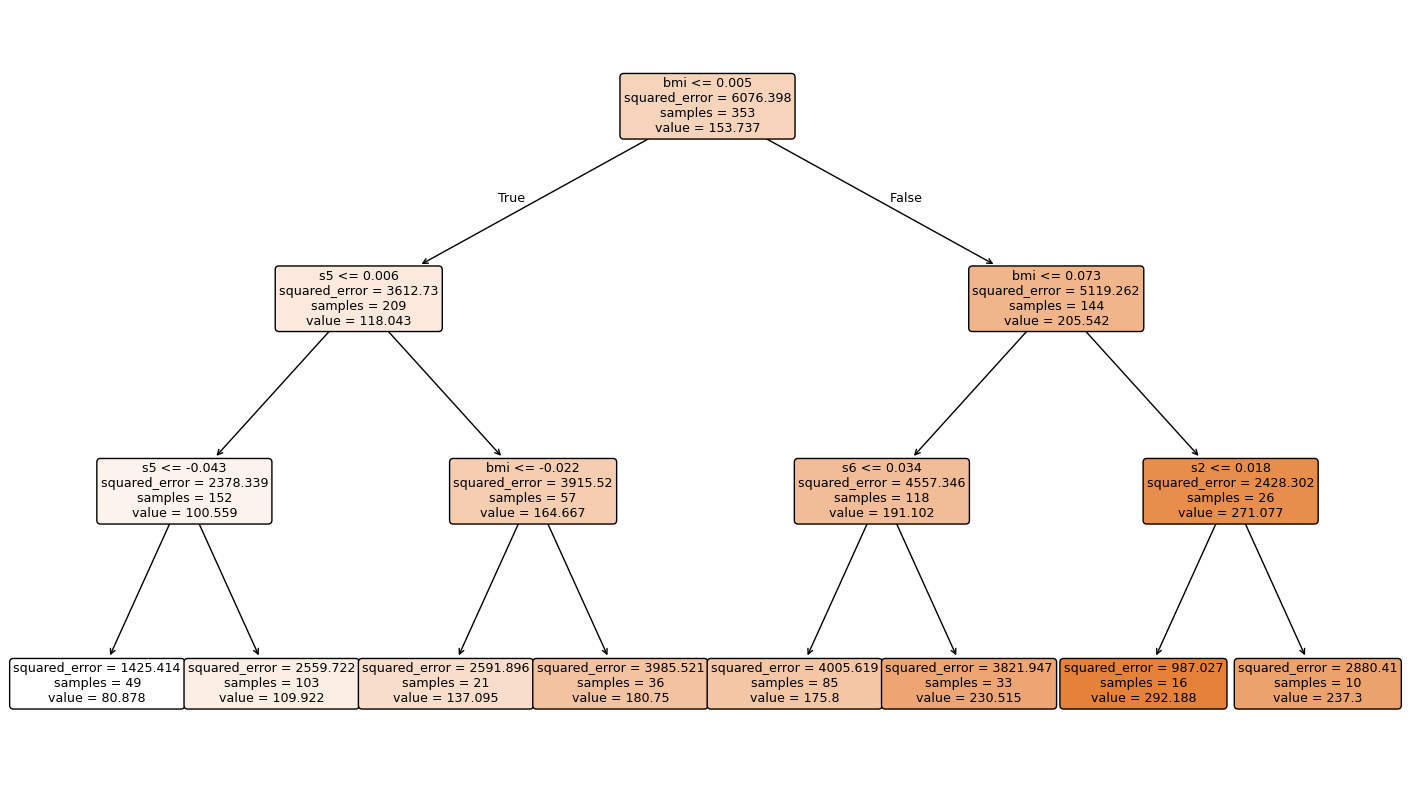

In [16]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    rounded=True
)

plt.show()

In [ ]:
model_before = DecisionTreeRegressor(random_state=42)

model_before.fit(X_train, y_train)

plt.figure(figsize=(30, 20))

plot_tree(
    model_before,
    feature_names=X.columns,
    filled=True,
    rounded=True
)

plt.show()

In [ ]:
model_after = DecisionTreeRegressor(
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=10,
    random_state=42
)

model_after.fit(X_train, y_train)

plt.figure(figsize=(20, 10))

plot_tree(
    model_after,
    feature_names=X.columns,
    filled=True,
    rounded=True
)

plt.show()